In [1]:
# Task 1: Data Visualization — Global Superstore Executive Dashboard

## Business Scenario
#Transform multi-dimensional sales, customer, and shipping performance records into an executive visual analytics dashboard. 

## Visual Deliverables
#1. **Executive KPI Card Grid:** Core top-line metrics (Gross Revenue, Total Orders, Profit Margin, Return Rate).
#2. **Geographical Market Breakdown:** Regional sales performance vs. regional profitability.
#3. **Category Profitability Matrix:** Multi-segment scatter visualization identifying high-margin versus loss-making product categories.
#4. **Temporal Seasonality Analysis:** Monthly revenue trajectories across customer segments.
#5. **Shipping Mode Efficiency Analysis:** Delivery speed versus shipping cost trade-offs.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Professional aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Visualization libraries configured successfully.")

Visualization libraries configured successfully.


In [2]:
## Step 2: Data Loading & Preparation
#We load a multi-attribute global commerce dataset tracking product sub-categories, market regions, financial returns, and shipping modes.
np.random.seed(42)
n_orders = 1200

dates = pd.date_range(start="2025-01-01", periods=365, freq="D")
regions = ["North America", "Europe", "Asia-Pacific", "Latin America", "Middle East"]
categories = ["Technology", "Furniture", "Office Supplies"]
sub_categories = {
    "Technology": ["Phones", "Laptops", "Accessories", "Copiers"],
    "Furniture": ["Chairs", "Tables", "Bookcases", "Furnishings"],
    "Office Supplies": ["Paper", "Binders", "Storage", "Art", "Envelopes"]
}
ship_modes = ["Same Day", "First Class", "Second Class", "Standard Class"]
segments = ["Consumer", "Corporate", "Home Office"]

records = []
for i in range(n_orders):
    cat = np.random.choice(categories, p=[0.35, 0.25, 0.40])
    sub_cat = np.random.choice(sub_categories[cat])
    qty = np.random.randint(1, 10)
    sales = np.round(np.random.exponential(scale=200) + 15, 2)
    # Profit logic with realistic occasional losses
    profit_margin = np.random.uniform(-0.15, 0.35) if cat != "Furniture" else np.random.uniform(-0.25, 0.20)
    profit = np.round(sales * profit_margin, 2)
    
    records.append({
        "Order_ID": f"ORD-{10000 + i}",
        "Order_Date": np.random.choice(dates),
        "Region": np.random.choice(regions, p=[0.30, 0.28, 0.22, 0.12, 0.08]),
        "Segment": np.random.choice(segments, p=[0.50, 0.30, 0.20]),
        "Category": cat,
        "Sub_Category": sub_cat,
        "Sales": sales,
        "Profit": profit,
        "Discount": np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5], p=[0.5, 0.2, 0.15, 0.1, 0.05]),
        "Ship_Mode": np.random.choice(ship_modes, p=[0.10, 0.20, 0.30, 0.40]),
        "Shipping_Cost": np.round(sales * np.random.uniform(0.04, 0.15), 2)
    })

df = pd.DataFrame(records)
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.strftime("%b")
df["Month_Num"] = df["Order_Date"].dt.month

df.to_csv("global_superstore_analytics.csv", index=False)
print(f"Dataset generated: {df.shape[0]} orders, {df.shape[1]} variables.")
display(df.head(3))

Dataset generated: 1200 orders, 13 variables.


,Order_ID,Order_Date,Region,Segment,Category,Sub_Category,Sales,Profit,Discount,Ship_Mode,Shipping_Cost,Month,Month_Num
0,ORD-10000,2025-08-03,North America,Home Office,Furniture,Chairs,197.59,-35.53,0.1,Standard Class,8.35,Aug,8
1,ORD-10001,2025-06-10,Europe,Corporate,Office Supplies,Art,15.16,5.25,0.0,First Class,1.63,Jun,6
2,ORD-10002,2025-05-11,Latin America,Corporate,Technology,Copiers,111.40,38.06,0.0,Same Day,16.00,May,5


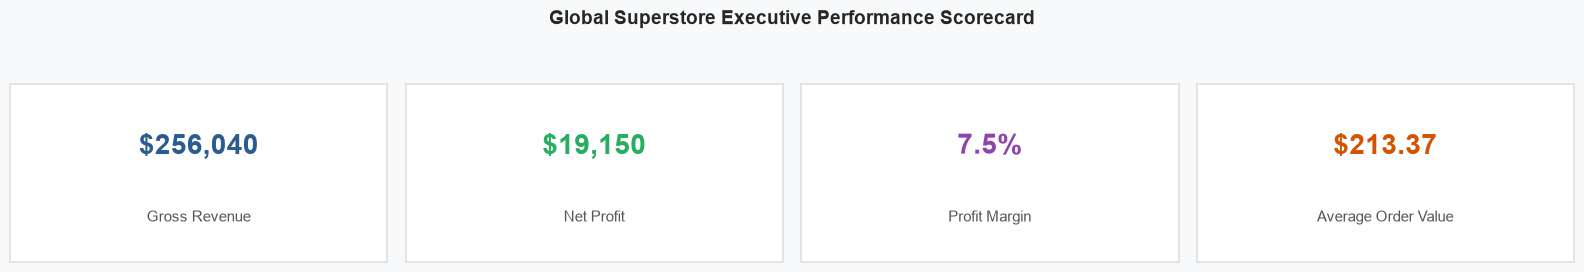

In [3]:
## Step 3: Executive KPI Summary Cards
#Summary cards displaying key financial indicators to ground leadership before detailed breakdowns.
total_revenue = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_revenue) * 100
total_orders = len(df)
avg_order_value = df["Sales"].mean()

fig, axes = plt.subplots(1, 4, figsize=(16, 2.5))
fig.patch.set_facecolor('#f8f9fa')

kpis = [
    ("Gross Revenue", f"${total_revenue:,.0f}", "#2b5c8f"),
    ("Net Profit", f"${total_profit:,.0f}", "#27ae60" if total_profit > 0 else "#c0392b"),
    ("Profit Margin", f"{profit_margin:.1f}%", "#8e44ad"),
    ("Average Order Value", f"${avg_order_value:.2f}", "#d35400")
]

for ax, (title, value, color) in zip(axes, kpis):
    ax.set_facecolor("white")
    ax.text(0.5, 0.65, value, fontsize=20, weight='bold', color=color, ha='center', va='center')
    ax.text(0.5, 0.25, title, fontsize=11, color='#555555', ha='center', va='center')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#e0e0e0')
        spine.set_linewidth(1.2)

plt.suptitle("Global Superstore Executive Performance Scorecard", fontsize=14, weight='bold', y=1.08)
plt.tight_layout()
plt.show()

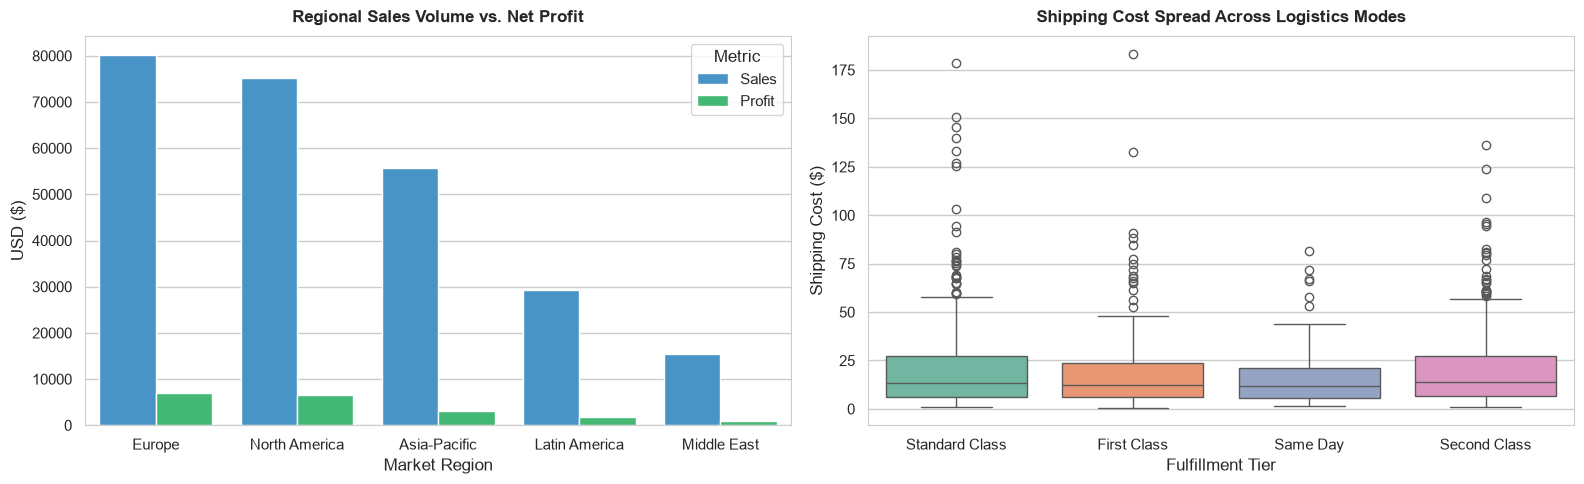

In [4]:
## Step 4: Regional Contribution & Shipping Efficiency
#Comparative bar and box visual designs exploring geographic market volume alongside shipping costs across transit tiers.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Regional Sales vs. Profit
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False).reset_index()
region_melted = region_summary.melt(id_vars="Region", value_vars=["Sales", "Profit"], var_name="Metric", value_name="Amount")

sns.barplot(data=region_melted, x="Region", y="Amount", hue="Metric", ax=axes[0], palette=["#3498db", "#2ecc71"])
axes[0].set_title("Regional Sales Volume vs. Net Profit", weight='bold', pad=10)
axes[0].set_ylabel("USD ($)")
axes[0].set_xlabel("Market Region")

# 2. Shipping Cost Distribution by Mode
sns.boxplot(data=df, x="Ship_Mode", y="Shipping_Cost", hue="Ship_Mode", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Shipping Cost Spread Across Logistics Modes", weight='bold', pad=10)
axes[1].set_ylabel("Shipping Cost ($)")
axes[1].set_xlabel("Fulfillment Tier")

plt.tight_layout()
plt.show()

findfont: Failed to find font weight semibold, now using 700.


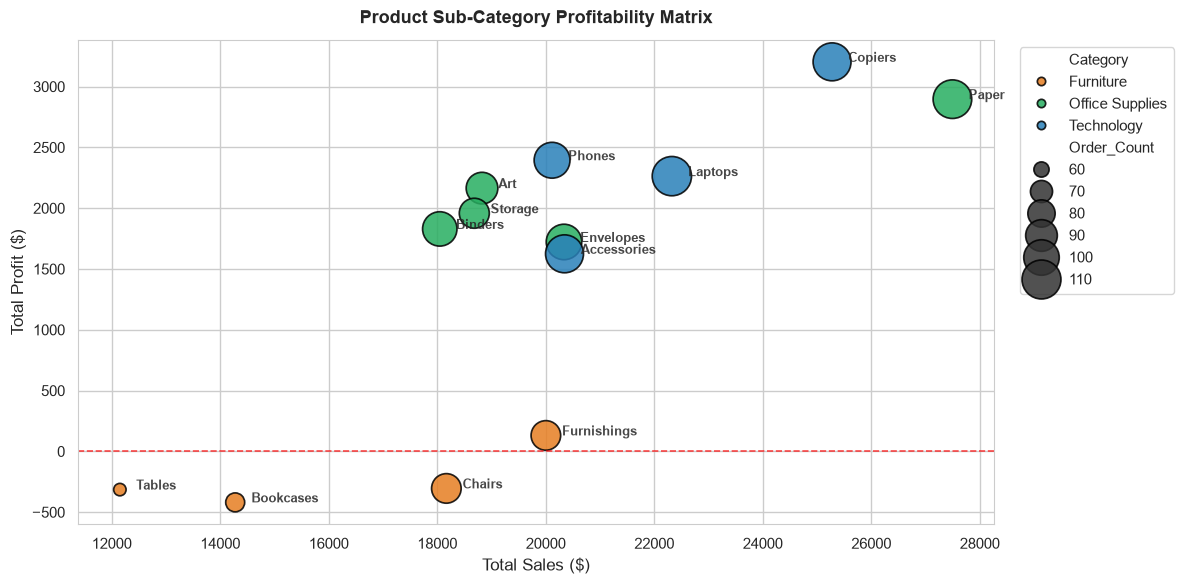

In [5]:
## Step 5: Strategic Sub-Category Profitability Matrix
#A multi-dimensional bubble chart plotting Sales against Profit across Sub-Categories, where bubble size reflects unit frequency and color encodes product category.
subcat_perf = df.groupby(["Category", "Sub_Category"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Order_Count=("Order_ID", "count")
).reset_index()

plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(
    data=subcat_perf,
    x="Total_Sales",
    y="Total_Profit",
    hue="Category",
    size="Order_Count",
    sizes=(80, 800),
    palette={"Technology": "#2980b9", "Furniture": "#e67e22", "Office Supplies": "#27ae60"},
    alpha=0.85,
    edgecolor="black"
)

plt.axhline(0, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
plt.title("Product Sub-Category Profitability Matrix", weight='bold', fontsize=13, pad=12)
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")

# Annotate each bubble
for _, row in subcat_perf.iterrows():
    plt.text(
        row["Total_Sales"] + 300, 
        row["Total_Profit"], 
        row["Sub_Category"], 
        fontsize=9, 
        alpha=0.85,
        weight='semibold'
    )

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

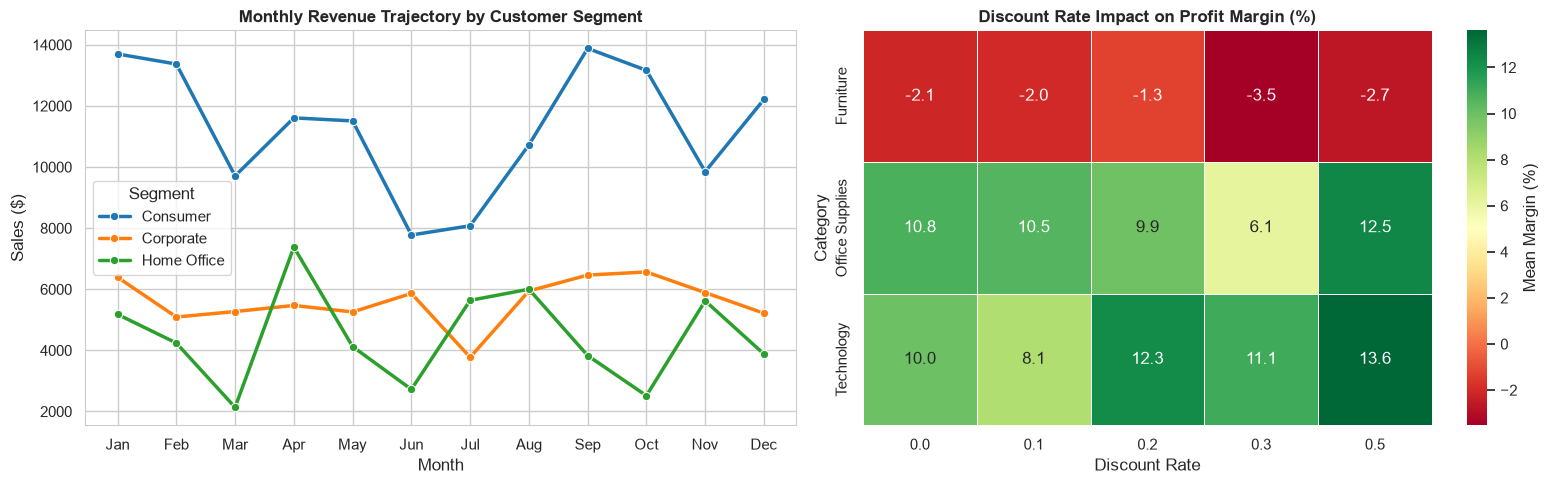

In [6]:
## Step 6: Monthly Revenue Trajectory & Discount-Profit Margin Heatmap
#Tracking revenue momentum over the calendar year and evaluating how escalating discounts impact category profit margins.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Monthly Revenue by Customer Segment
monthly_segment = df.groupby(["Month_Num", "Month", "Segment"])["Sales"].sum().reset_index()
monthly_segment = monthly_segment.sort_values("Month_Num")

sns.lineplot(data=monthly_segment, x="Month", y="Sales", hue="Segment", marker="o", linewidth=2.5, ax=axes[0], palette="tab10")
axes[0].set_title("Monthly Revenue Trajectory by Customer Segment", weight='bold')
axes[0].set_ylabel("Sales ($)")
axes[0].set_xlabel("Month")

# 2. Discount Level vs. Profit Margin by Category
df["Profit_Margin_Pct"] = (df["Profit"] / df["Sales"]) * 100
heatmap_data = df.pivot_table(index="Category", columns="Discount", values="Profit_Margin_Pct", aggfunc="mean")

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={'label': 'Mean Margin (%)'}, ax=axes[1], linewidths=0.5)
axes[1].set_title("Discount Rate Impact on Profit Margin (%)", weight='bold')
axes[1].set_xlabel("Discount Rate")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()